# Clusterização de Municípios Brasileiros — Análise Exploratória (EDA)

**Objetivo:** agrupar municípios brasileiros semelhantes com base em características demográficas e econômicas, sem usar rótulos.

**Fonte dos dados:** IBGE (Instituto Brasileiro de Geografia e Estatística), via API oficial de localidades e API SIDRA. O IBGE é o órgão federal responsável pelos dados também catalogados no [Portal Brasileiro de Dados Abertos](https://dados.gov.br). O script de coleta está em `../src/baixar_dados.py`.

Este notebook contém **somente EDA** (análise exploratória). Nenhum modelo de clusterização é treinado aqui — isso é feito nos notebooks seguintes (`02_Baseline`, `03_Comparacao_Modelos`, `04_Avaliacao_Conclusao`).

**Variáveis do dataset (nível município, ano de referência 2021):**
- `codigo_municipio`, `municipio`: identificação
- `uf_sigla`, `uf_nome`, `regiao`, `mesorregiao`, `microrregiao`: localização geográfica (categóricas)
- `populacao`: população estimada
- `pib_total_mil_reais`: Produto Interno Bruto total (mil R$)
- `vab_agropecuaria_mil_reais`, `vab_industria_mil_reais`, `vab_servicos_mil_reais`, `vab_adm_publica_mil_reais`: valor adicionado bruto por setor econômico (mil R$)
- `pib_per_capita_reais`: PIB per capita (R$), calculado a partir do PIB total e da população

## 1. Imports e configuração

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

PASTA_REPORTS = "../reports"
os.makedirs(PASTA_REPORTS, exist_ok=True)

## 2. Carregar os dados

In [2]:
CAMINHO_DADOS = "../data/municipios_brasil.csv"

df = pd.read_csv(CAMINHO_DADOS)
print("Linhas x Colunas:", df.shape)
df.head()

Linhas x Colunas: (5571, 14)


,codigo_municipio,municipio,uf_sigla,uf_nome,regiao,mesorregiao,microrregiao,populacao,pib_total_mil_reais,vab_adm_publica_mil_reais,vab_agropecuaria_mil_reais,vab_industria_mil_reais,vab_servicos_mil_reais,pib_per_capita_reais
0,1100015,Alta Floresta D'Oeste,RO,Rondônia,Norte,Leste Rondoniense,Cacoal,22516.0,734467.0,173122.0,311469.0,27845.0,172435.0,32619.781489
1,1100023,Ariquemes,RO,Rondônia,Norte,Leste Rondoniense,Ariquemes,111148.0,3211294.0,782306.0,293001.0,407675.0,1307977.0,28892.053838
2,1100031,Cabixi,RO,Rondônia,Norte,Leste Rondoniense,Colorado do Oeste,5067.0,238414.0,46579.0,136659.0,8117.0,35866.0,47052.299191
3,1100049,Cacoal,RO,Rondônia,Norte,Leste Rondoniense,Cacoal,86416.0,2792506.0,629109.0,341315.0,236801.0,1200654.0,32314.687095
4,1100056,Cerejeiras,RO,Rondônia,Norte,Leste Rondoniense,Colorado do Oeste,16088.0,743062.0,123365.0,151690.0,27433.0,308668.0,46187.344605


## 3. Qualidade dos dados

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5571 entries, 0 to 5570
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   codigo_municipio            5571 non-null   int64  
 1   municipio                   5571 non-null   str    
 2   uf_sigla                    5571 non-null   str    
 3   uf_nome                     5571 non-null   str    
 4   regiao                      5571 non-null   str    
 5   mesorregiao                 5570 non-null   str    
 6   microrregiao                5570 non-null   str    
 7   populacao                   5570 non-null   float64
 8   pib_total_mil_reais         5570 non-null   float64
 9   vab_adm_publica_mil_reais   5570 non-null   float64
 10  vab_agropecuaria_mil_reais  5570 non-null   float64
 11  vab_industria_mil_reais     5570 non-null   float64
 12  vab_servicos_mil_reais      5570 non-null   float64
 13  pib_per_capita_reais        5570 non-null   

In [4]:
# Valores nulos por coluna
nulos = df.isnull().sum().sort_values(ascending=False)
nulos[nulos > 0]

mesorregiao                   1
vab_agropecuaria_mil_reais    1
vab_adm_publica_mil_reais     1
pib_total_mil_reais           1
populacao                     1
microrregiao                  1
vab_servicos_mil_reais        1
vab_industria_mil_reais       1
pib_per_capita_reais          1
dtype: int64

In [5]:
# Município(s) com dado ausente (série do IBGE incompleta para município recém-criado)
df[df["populacao"].isnull()]

,codigo_municipio,municipio,uf_sigla,uf_nome,regiao,mesorregiao,microrregiao,populacao,pib_total_mil_reais,vab_adm_publica_mil_reais,vab_agropecuaria_mil_reais,vab_industria_mil_reais,vab_servicos_mil_reais,pib_per_capita_reais
5199,5101837,Boa Esperança do Norte,MT,Mato Grosso,Centro-Oeste,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Linhas duplicadas
print("Duplicadas:", df.duplicated().sum())
print("Códigos de município duplicados:", df["codigo_municipio"].duplicated().sum())

Duplicadas: 0
Códigos de município duplicados: 0


## 4. Estatísticas descritivas

In [7]:
colunas_numericas = [
    "populacao",
    "pib_total_mil_reais",
    "vab_agropecuaria_mil_reais",
    "vab_industria_mil_reais",
    "vab_servicos_mil_reais",
    "vab_adm_publica_mil_reais",
    "pib_per_capita_reais",
]

df[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
populacao,5570.0,3.829760e+04,2.242882e+05,771.000000,5454.000000,11732.000000,25764.750000,1.239637e+07
pib_total_mil_reais,5570.0,1.617979e+06,1.377458e+07,18051.000000,112636.000000,253180.000000,680951.500000,8.289807e+08
vab_agropecuaria_mil_reais,5570.0,1.061194e+05,2.391838e+05,0.000000,16730.250000,43537.500000,103988.500000,5.004239e+06
vab_industria_mil_reais,5570.0,3.579531e+05,2.115983e+06,-477324.000000,5134.000000,17509.500000,105457.750000,6.561607e+07
vab_servicos_mil_reais,5570.0,7.020034e+05,8.354447e+06,2713.000000,25501.250000,64896.500000,206696.000000,5.497675e+08
vab_adm_publica_mil_reais,5570.0,2.188431e+05,1.935301e+06,8460.000000,32688.500000,61832.000000,134040.750000,1.168092e+08
pib_per_capita_reais,5570.0,3.387307e+04,4.190939e+04,5406.450671,12831.691759,23372.934863,40810.870685,9.208284e+05


**Leitura estatística da tabela acima:**

- Em todas as variáveis, a **média é muito maior que a mediana** — sinal claro de assimetria à direita (cauda longa de valores grandes puxando a média para cima). A razão média/mediana é especialmente extrema em `vab_industria_mil_reais` (~20x) e `vab_servicos_mil_reais` (~11x), contra apenas ~1,45x em `pib_per_capita_reais`. Isso já indica que o PIB per capita é uma variável muito mais "bem-comportada" (relativa/normalizada) do que os totais absolutos.
- O **coeficiente de variação (CV = desvio-padrão / média)** mede o quanto os valores variam *em relação ao próprio tamanho médio* — ao contrário do desvio-padrão sozinho, o CV não depende da unidade/escala da variável, então dá pra comparar a dispersão de `populacao` (pessoas) com a de `pib_total_mil_reais` (mil R$) diretamente. Na prática: CV baixo (perto de 0) = valores concentrados perto da média; CV alto = valores muito espalhados, com a dispersão superando a própria média. Aqui isso confirma o que a razão média/mediana já sugeria: `pib_total_mil_reais` tem CV ≈ 8,5 e `vab_servicos_mil_reais` CV ≈ 11,9 (dispersão muitas vezes maior que a própria média — ou seja, "o município típico" está longe de representar o grupo), enquanto `pib_per_capita_reais` tem CV ≈ 1,2 — ainda alto, mas em outra ordem de grandeza.
- O mínimo de `vab_industria_mil_reais` é **negativo** (-477.324 mil R$), o que é logicamente impossível para um valor adicionado bruto e será investigado a seguir.
- Máximos multiplicam o 3º quartil por 100-1000x em quase todas as colunas (ex.: `pib_total_mil_reais` vai de R$ 681 milhões no p75 para R$ 829 bilhões no máximo) — forte indício de outliers extremos de escala (grandes metrópoles), não de erros de digitação isolados.

In [8]:
# Valores negativos são inesperados nas colunas de PIB/VAB (deveriam ser sempre >= 0)
for col in colunas_numericas:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f"{col}: {n_neg} valor(es) negativo(s)")
        display(df.loc[df[col] < 0, ["municipio", "uf_sigla", col]])

vab_industria_mil_reais: 1 valor(es) negativo(s)


,municipio,uf_sigla,vab_industria_mil_reais
5368,Cachoeira Dourada,GO,-477324.0


## 5. Distribuição geográfica (variáveis categóricas)

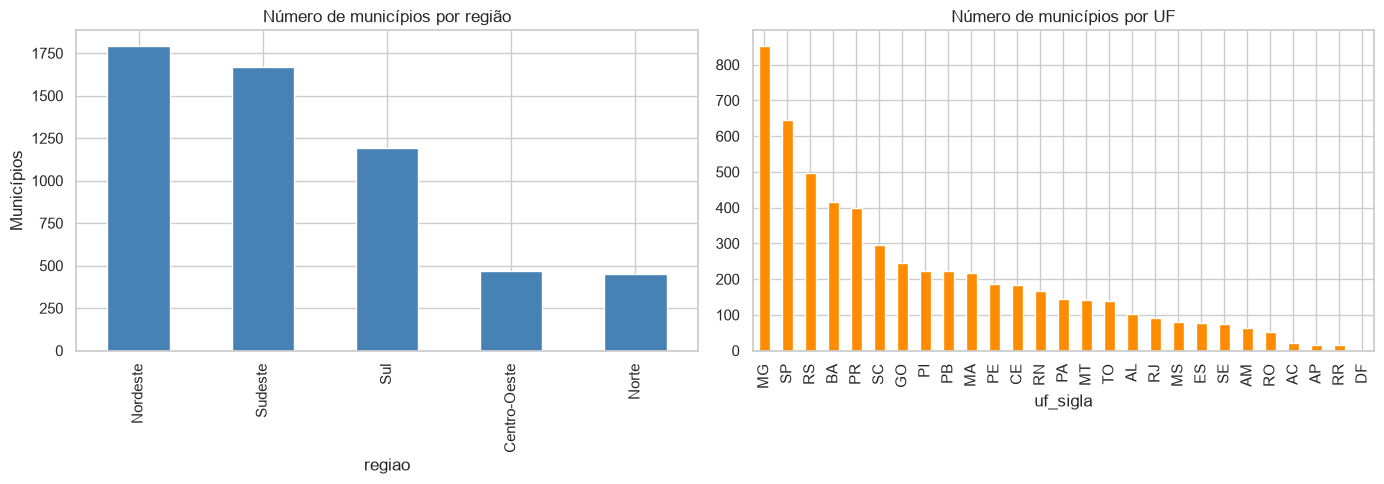

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["regiao"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Número de municípios por região")
axes[0].set_ylabel("Municípios")

df["uf_sigla"].value_counts().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Número de municípios por UF")

plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/eda_municipios_por_regiao_uf.png", dpi=120)
plt.show()

**Leitura estatística:** a distribuição de municípios entre regiões não é uniforme — Nordeste (1.794 municípios, 32,2% do total) e Sudeste (1.668, 29,9%) concentram, juntas, quase dois terços dos municípios do país, enquanto Centro-Oeste (468, 8,4%) e Norte (450, 8,1%) têm as menores contagens. Isso reflete o histórico de fragmentação municipal (Nordeste tem muitos municípios pequenos e antigos) mais do que necessariamente população ou riqueza.

No recorte por UF, Minas Gerais (853 municípios) e São Paulo (645) concentram sozinhos ~27% de todos os municípios do Brasil, enquanto Amapá (16) e Roraima (15) têm poucas dezenas — e o Distrito Federal é, por definição, uma única unidade (não é dividido em municípios). Como o número de municípios por UF não guarda relação direta com população ou PIB da UF, essa variável funciona melhor como **sinal de contexto geográfico** (útil para KModes/KPrototypes) do que como proxy de porte econômico.

## 6. Distribuições das variáveis numéricas

As variáveis de população e PIB tendem a ser fortemente assimétricas (poucos municípios muito grandes, como capitais, e a maioria pequena). Comparamos a escala original com a transformação `log1p`.

**Por que aplicar `log1p` — e por que isso importa além do histograma ficar "mais bonito":** reduzir a assimetria não é um ajuste cosmético, é o que torna duas outras análises deste notebook confiáveis:
1. **Correlação (Seção 8):** a correlação de Pearson é sensível a valores extremos — calculada na escala bruta, ela fica dominada por meia dúzia de mega-cidades e não representa a relação entre a maioria dos municípios (mostramos os números logo na Seção 8).
2. **Clusterização (notebooks seguintes):** algoritmos como KMeans e DBSCAN agrupam pontos com base em distância (normalmente euclidiana). Sem o `log1p`, mesmo depois de padronizar (`StandardScaler`), a variância de cada coluna continuaria dominada pelos outliers extremos — a imensa maioria dos municípios "normais" ficaria espremida perto de zero, e o modelo acabaria só separando "as poucas mega-cidades" do resto, em vez de encontrar uma estrutura que faça sentido para todos os 5.570 municípios.

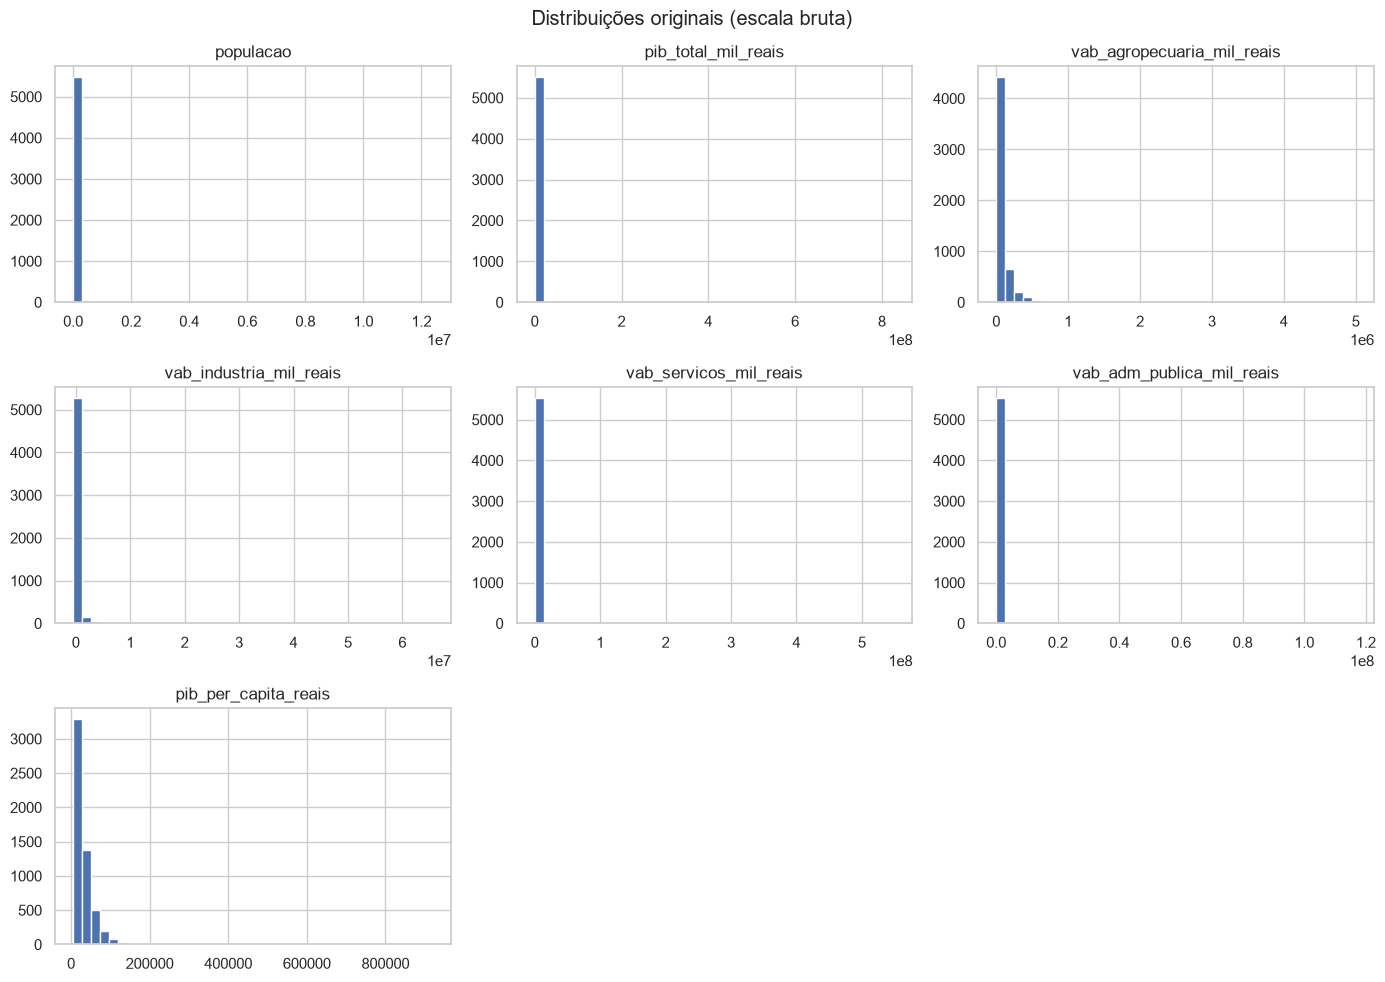

In [10]:
df[colunas_numericas].hist(figsize=(14, 10), bins=40)
plt.suptitle("Distribuições originais (escala bruta)")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/eda_distribuicoes_originais.png", dpi=120)
plt.show()

**Leitura estatística:** os histogramas confirmam numericamente o que a tabela de estatísticas já sugeria. A assimetria (*skewness*) na escala bruta é extrema em todas as variáveis:

| Variável | Skewness | Curtose |
|---|---:|---:|
| `populacao` | 37,1 | 1.823 |
| `pib_total_mil_reais` | 44,3 | 2.455 |
| `vab_servicos_mil_reais` | 53,8 | 3.399 |
| `vab_adm_publica_mil_reais` | 46,8 | 2.568 |
| `vab_industria_mil_reais` | 17,7 | 419 |
| `vab_agropecuaria_mil_reais` | 9,0 | 122 |
| `pib_per_capita_reais` | 7,9 | 111 |

Para referência, uma distribuição normal tem skewness = 0 e curtose = 0 (ou 3, na convenção não-centrada). Valores de skewness acima de 1 já são considerados "altamente assimétricos" na literatura — aqui estamos na casa de dezenas, e a curtose (leptocurtose extrema) confirma picos muito concentrados perto de zero com caudas extremamente longas. Isso inviabiliza qualquer algoritmo de clusterização baseado em distância euclidiana sem transformação prévia, pois a variância seria dominada por meia dúzia de outliers (as grandes capitais).

C:\Users\edd-j\Downloads\Conteudos\APOENA\Projeto_na_Pratica\Clusterizacao\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


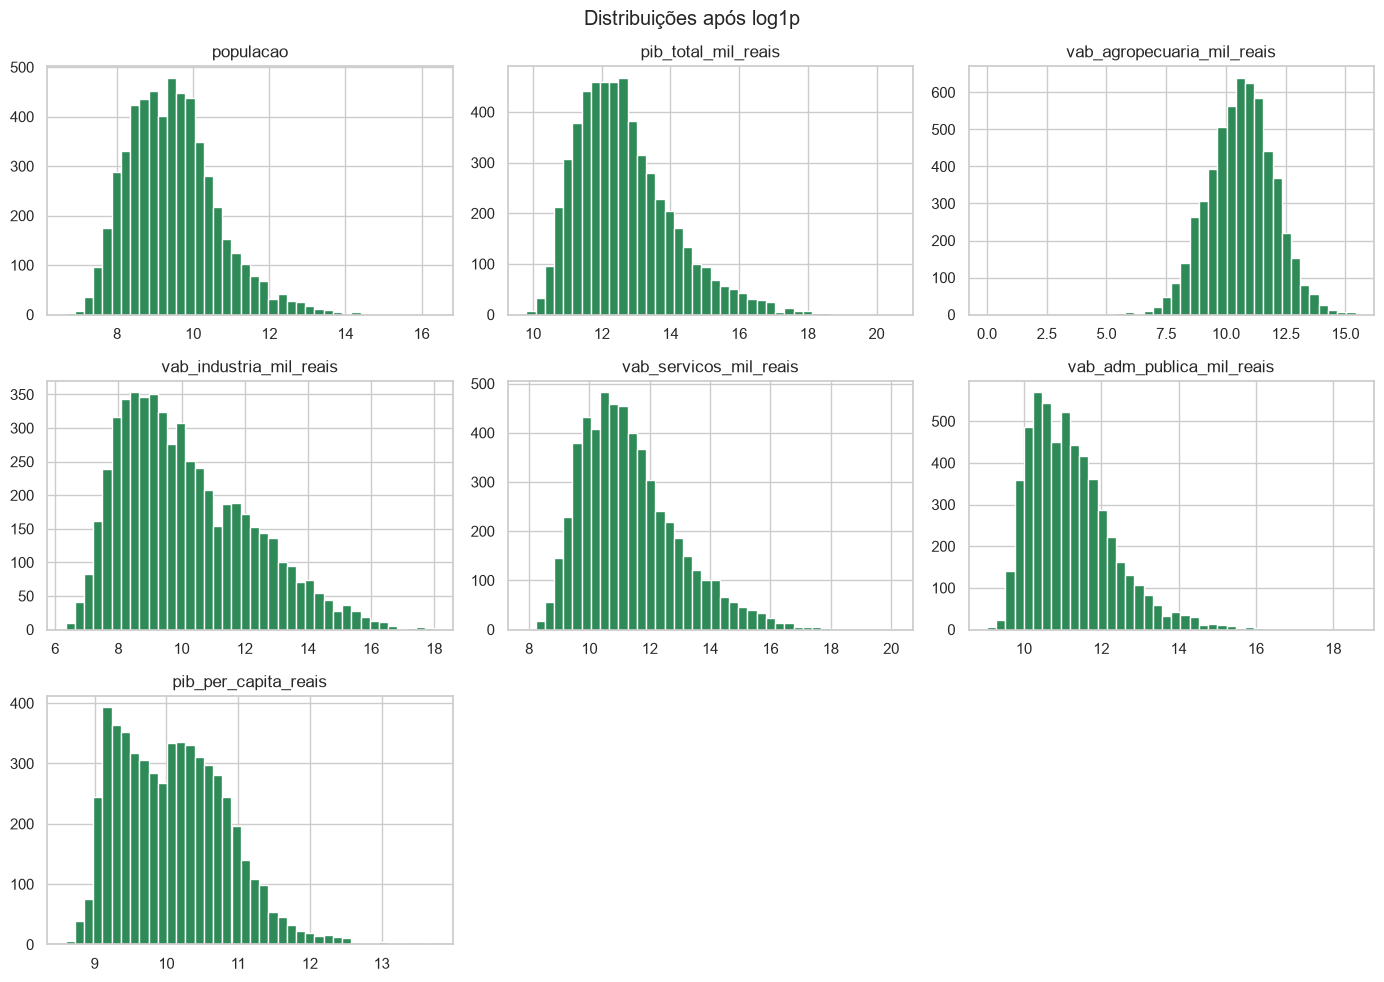

In [11]:
df_log = np.log1p(df[colunas_numericas])
df_log.hist(figsize=(14, 10), bins=40, color="seagreen")
plt.suptitle("Distribuições após log1p")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/eda_distribuicoes_log.png", dpi=120)
plt.show()

**Leitura estatística:** o `log1p` reduz drasticamente a assimetria — `populacao` cai de skewness 37,1 para 0,80, e `pib_total_mil_reais` de 44,3 para 0,97. Na prática, a maioria das variáveis passa de "extremamente assimétrica" para "levemente assimétrica" (skewness entre -0,3 e 1,2), faixa em que medidas de distância euclidiana deixam de ser dominadas por uma minúscula fração de outliers. `vab_agropecuaria_mil_reais` inclusive fica com leve assimetria **negativa** (-0,26) após o log, e `vab_adm_publica_mil_reais` é a que sobra mais assimétrica (1,15) — ainda assim, uma redução de ~40x em relação à escala bruta. Essa é a evidência quantitativa que justifica aplicar `log1p` antes de qualquer padronização nos notebooks seguintes.

## 7. Outliers

Poucos municípios concentram uma fração enorme da população e do PIB nacional (grandes capitais). Isso é esperado e será tratado com transformação logarítmica e/ou padronização robusta antes da modelagem.

In [12]:
# Os 10 maiores municípios em população e em PIB
print("Top 10 população:")
display_cols = ["municipio", "uf_sigla", "populacao", "pib_total_mil_reais", "pib_per_capita_reais"]
print(df.nlargest(10, "populacao")[display_cols].to_string(index=False))

print("\nTop 10 PIB total:")
print(df.nlargest(10, "pib_total_mil_reais")[display_cols].to_string(index=False))

Top 10 população:
     municipio uf_sigla  populacao  pib_total_mil_reais  pib_per_capita_reais
     São Paulo       SP 12396372.0          828980747.0          66872.851750
Rio de Janeiro       RJ  6775561.0          359632648.0          53077.914582
      Brasília       DF  3094325.0          286943782.0          92732.270204
      Salvador       BA  2900319.0           62981326.0          21715.309937
     Fortaleza       CE  2703391.0           73437739.0          27165.045308
Belo Horizonte       MG  2530701.0          105920859.0          41854.355374
        Manaus       AM  2255903.0          103281400.0          45782.730906
      Curitiba       PR  1963726.0           98000491.0          49905.379366
        Recife       PE  1661017.0           54970302.0          33094.364477
       Goiânia       GO  1555626.0           59870499.0          38486.435043

Top 10 PIB total:
     municipio uf_sigla  populacao  pib_total_mil_reais  pib_per_capita_reais
     São Paulo       SP 123

**Leitura estatística — concentração:**

| Fatia | % da população nacional | % do PIB nacional |
|---|---:|---:|
| Top 10 municípios (0,2% do total) | 17,7% | 23,5% |
| Top 50 municípios (0,9% do total) | 32,1% | 42,1% |
| Top 100 municípios (1,8% do total) | 40,7% | 52,2% |

Ou seja: **menos de 2% dos municípios concentram mais da metade do PIB do país**, e menos de 1 em cada 1000 municípios (os 10 maiores) já responde por quase um quarto da riqueza nacional. O PIB de São Paulo sozinho (R$ 829 bilhões) equivale à soma dos ~4.040 municípios de menor PIB do dataset (de um total de 5.570) — cerca de 73% de todos os municípios juntos. Esse grau de concentração é consistente com o padrão de "lei de potência" (*power law*) típico de variáveis socioeconômicas em escala nacional (população e renda de cidades, tamanho de empresas, etc.), e reforça por que a transformação logarítmica — que "achata" leis de potência em algo aproximadamente linear — é indispensável aqui.

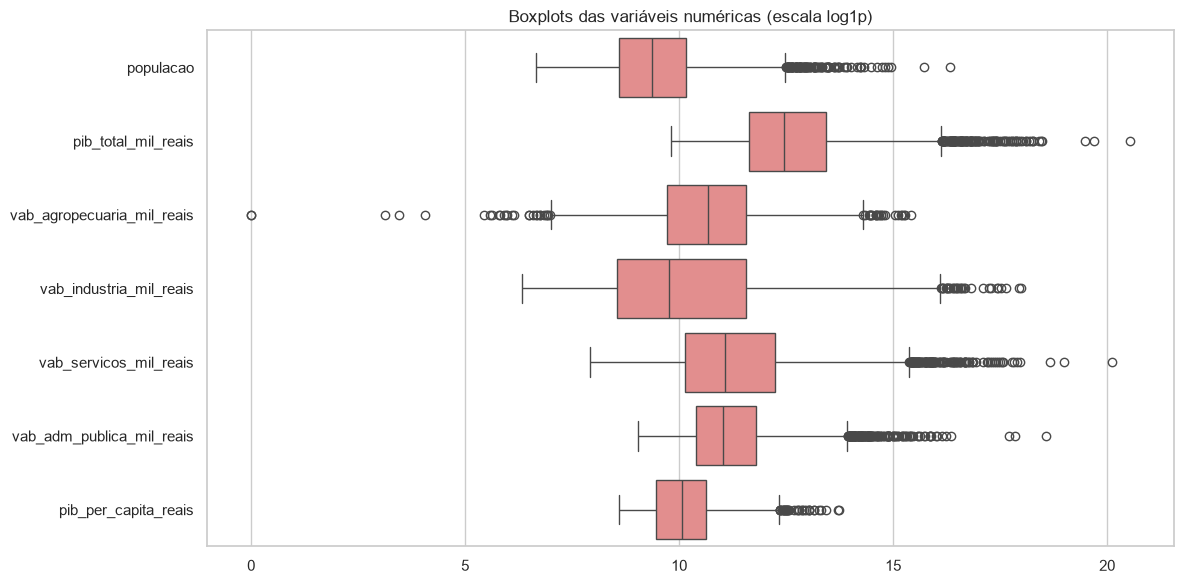

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_log, orient="h", ax=ax, color="lightcoral")
ax.set_title("Boxplots das variáveis numéricas (escala log1p)")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/eda_boxplots_log.png", dpi=120)
plt.show()

**Leitura estatística:** mesmo após o `log1p`, a regra do IQR (pontos além de 1,5×IQR dos quartis) ainda identifica outliers residuais em todas as variáveis — entre 0,6% (`vab_industria_mil_reais`, `pib_per_capita_reais`) e 2,7% (`vab_adm_publica_mil_reais`) dos municípios, ou seja, de 32 a 148 municípios por variável. Isso é esperado e **não é um problema a "corrigir"**: são as grandes capitais e polos regionais, que continuam sendo estatisticamente atípicos mesmo em escala logarítmica, simplesmente porque a distribuição de tamanho de cidades tem cauda longa por natureza. A decisão do projeto é manter esses pontos (não removê-los como erro), já que representam municípios reais e relevantes — o objetivo da clusterização é justamente separar esse grupo do restante, não descartá-lo.

## 8. Correlações

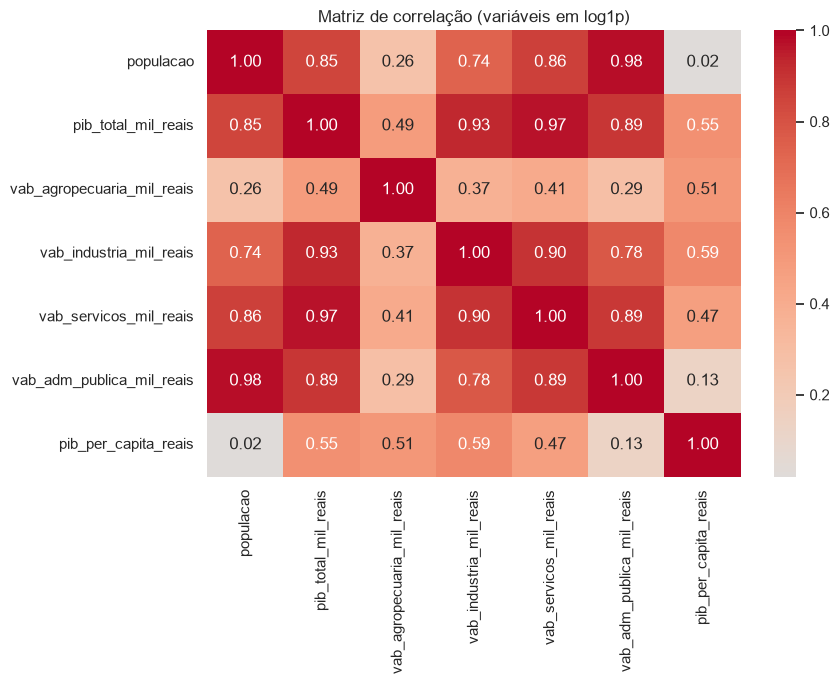

In [14]:
plt.figure(figsize=(9, 7))
sns.heatmap(df_log.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação (variáveis em log1p)")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/eda_correlacoes.png", dpi=120)
plt.show()

**Por que essa matriz é calculada em `log1p`, e não na escala bruta?** Porque a correlação de Pearson mede relação *linear* e é sensível a valores extremos — na escala bruta, os poucos municípios gigantes dominam a conta. Para provar isso, comparamos a correlação `populacao` × `pib_total_mil_reais` com e sem os 100 maiores municípios:

| | Base completa | Sem os 100 maiores municípios |
|---|---:|---:|
| Correlação em escala **bruta** | 0,954 | 0,631 |
| Correlação em escala **log1p** | 0,848 | 0,816 |

Na escala bruta, a correlação despenca de 0,95 para 0,63 só de remover 1,8% dos municípios — ou seja, aquele 0,95 descreve principalmente as mega-cidades, não o Brasil como um todo. Em log1p, a mesma remoção quase não move a correlação (0,85 → 0,82): ela reflete a relação entre a maioria dos 5.570 municípios, não só os extremos. Isso acontece porque a relação população-PIB é mais próxima de **proporcional** (dobrar a população tende a dobrar o PIB) do que aditiva, e relação proporcional só vira reta — o que Pearson mede bem — em escala log-log (a conta completa, com regressão e r², está na Seção 9).

**Leitura estatística:** três padrões se destacam na matriz:

1. **Multicolinearidade forte entre porte e PIB**, como esperado: `populacao` correlaciona 0,98 com `vab_adm_publica` (a maior correlação de toda a matriz — o gasto/valor gerado pela administração pública escala quase 1:1 com o número de habitantes atendidos), 0,86 com `vab_servicos` e 0,85 com `pib_total`. Já `pib_total` chega a 0,97 com `vab_servicos` e 0,93 com `vab_industria` (natural, pois um é soma dos outros). Usar todas essas variáveis juntas em um modelo de distância dá peso implícito repetido à mesma dimensão latente de "tamanho".
2. **`populacao` e `pib_per_capita_reais` são praticamente não correlacionadas** (r = 0,02). Este é um achado relevante: **tamanho populacional não prediz riqueza por habitante** — existem municípios pequenos ricos (ex.: sedes de operações industriais/energéticas) e municípios grandes pobres. Isso justifica manter `pib_per_capita_reais` como feature própria, pois carrega informação que as variáveis de escala não capturam.
3. **A composição setorial importa para a riqueza per capita, mas de forma desigual**: `pib_per_capita_reais` correlaciona 0,59 com `vab_industria`, 0,55 com `pib_total` e 0,51 com `vab_agropecuaria`, mas apenas 0,13 com `vab_adm_publica` — indicando que municípios com economia mais industrializada tendem a ser mais ricos por habitante, enquanto ter um setor público grande (em termos absolutos) não se traduz necessariamente em maior renda per capita.

## 9. Relação entre variáveis e região

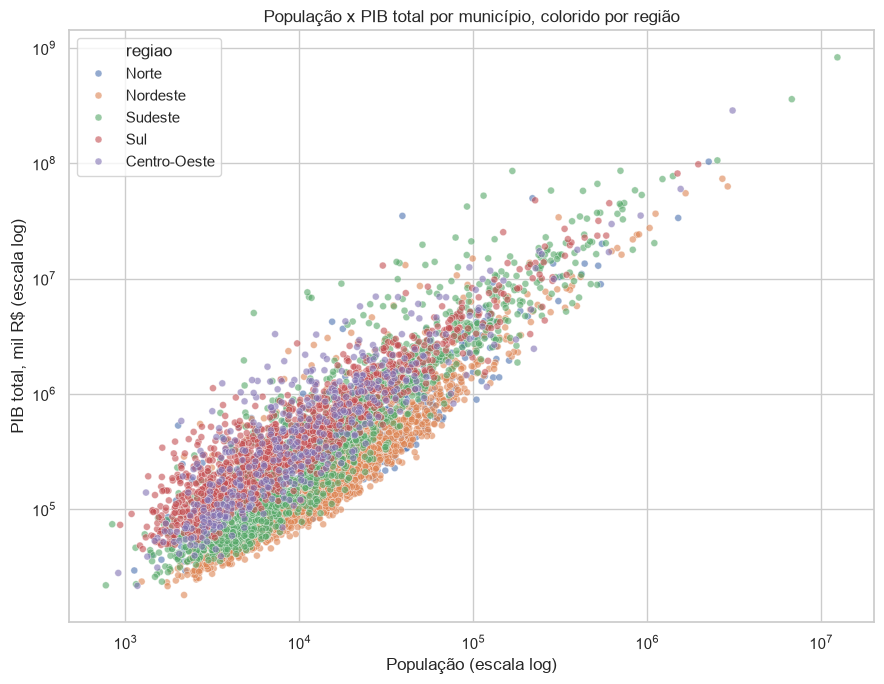

In [15]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df,
    x="populacao",
    y="pib_total_mil_reais",
    hue="regiao",
    alpha=0.6,
    s=25,
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("População (escala log)")
plt.ylabel("PIB total, mil R$ (escala log)")
plt.title("População x PIB total por município, colorido por região")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/eda_populacao_vs_pib.png", dpi=120)
plt.show()

In [16]:
# Quantificando a relação vista no gráfico: correlação e regressão em escala log1p
log_pop = np.log1p(df["populacao"])
log_pib = np.log1p(df["pib_total_mil_reais"])
mask_validos = log_pop.notna() & log_pib.notna()

r = log_pop[mask_validos].corr(log_pib[mask_validos])
inclinacao, intercepto = np.polyfit(log_pop[mask_validos], log_pib[mask_validos], deg=1)

print(f"Correlação (r):           {r:.3f}")
print(f"Coeficiente de determinação (r²): {r**2:.3f}")
print(f"Inclinação da reta (elasticidade): {inclinacao:.2f}")

# Sensibilidade a outliers: mesma correlação, removendo as cidades mais populosas
df_ordenado = df.sort_values("populacao", ascending=False)
r_bruto_completo = df_ordenado["populacao"].corr(df_ordenado["pib_total_mil_reais"])
r_bruto_sem_top100 = df_ordenado.iloc[100:]["populacao"].corr(df_ordenado.iloc[100:]["pib_total_mil_reais"])
r_log_completo = np.log1p(df_ordenado["populacao"]).corr(np.log1p(df_ordenado["pib_total_mil_reais"]))
r_log_sem_top100 = np.log1p(df_ordenado.iloc[100:]["populacao"]).corr(
    np.log1p(df_ordenado.iloc[100:]["pib_total_mil_reais"])
)

print("\nEstabilidade da correlação ao remover os 100 maiores municípios:")
print(f"  Escala bruta: {r_bruto_completo:.3f} -> {r_bruto_sem_top100:.3f}  (queda de {r_bruto_completo - r_bruto_sem_top100:.3f})")
print(f"  Escala log1p: {r_log_completo:.3f} -> {r_log_sem_top100:.3f}  (queda de {r_log_completo - r_log_sem_top100:.3f})")

Correlação (r):           0.848
Coeficiente de determinação (r²): 0.719
Inclinação da reta (elasticidade): 1.01

Estabilidade da correlação ao remover os 100 maiores municípios:
  Escala bruta: 0.954 -> 0.631  (queda de 0.323)
  Escala log1p: 0.848 -> 0.816  (queda de 0.032)


**Leitura estatística:** em escala log-log, a relação população × PIB tem correlação r = 0,85 (r² ≈ 0,72 — a população explica cerca de 72% da variância do log do PIB) e uma **inclinação da reta de regressão ≈ 1,01**, ou seja, aproximadamente **elasticidade unitária**: em média, um aumento de 1% na população acompanha um aumento de ~1% no PIB total, o que é consistente com o PIB per capita médio ser relativamente estável ao longo da escala de municípios (reforçando o achado da seção de correlação: `populacao` e `pib_per_capita_reais` são quase independentes). Ainda assim, os ~28% de variância não explicados pela população — visíveis como dispersão vertical em torno da reta — são justamente o espaço onde a composição setorial e a localização geográfica diferenciam municípios de tamanho parecido, e é esse "resíduo" que a clusterização busca capturar.

*(Por que medir em `log1p` em vez da escala bruta — com os números de estabilidade da correlação removendo outliers — foi mostrado na Seção 8.)*

A cor por região revela que esse "resíduo" não é aleatório — ele tem padrão geográfico. Olhando a mediana de PIB per capita por região (não é o eixo do gráfico, mas explica o posicionamento vertical dos pontos coloridos em relação à reta): Sul (R$ 43.022) e Centro-Oeste (R$ 38.486) têm as maiores medianas — seus municípios tendem a ficar **acima** da reta de tendência (mais PIB do que o esperado para a população que têm) — enquanto Nordeste (R$ 11.499) e Norte (R$ 18.602) têm as menores, tendendo a ficar **abaixo** da reta. Curiosamente, população mediana e riqueza per capita não andam juntas por região: o Norte tem a **maior** população mediana entre as 5 regiões (16.921 hab.) mas uma das PIBs per capita mais baixas, enquanto o Sul tem a **menor** população mediana (7.213 hab.) e a maior renda per capita — outro reflexo de que porte e riqueza por habitante são fenômenos distintos, algo que a clusterização final (notebook `04`) explora com mais profundidade.

## 10. Conclusões da EDA

- O dataset tem 5.571 municípios e apenas 1 registro com valores ausentes (município recém-criado sem série histórica de PIB no IBGE); a linha será removida antes da modelagem.
- Não há linhas duplicadas.
- Um município (Cachoeira Dourada - GO) apresenta VAB da indústria negativo — uma peculiaridade real da série do IBGE (município sede de usina hidrelétrica, com contabilização atípica de impostos/subsídios do setor elétrico). Como `log1p` não é definido para valores menores que -1, esse valor será limitado a 0 (`clip`) antes da transformação logarítmica.
- As variáveis numéricas (população, PIB, VAB setorial) são fortemente assimétricas à direita — poucas grandes capitais concentram a maior parte do PIB e da população do país. A transformação `log1p` deixa as distribuições muito mais próximas do normal, o que favorece algoritmos baseados em distância (KMeans, DBSCAN, Agglomerative).
- `pib_total_mil_reais` é fortemente correlacionado com seus componentes setoriais (agropecuária, indústria, serviços, administração pública), o que é esperado, pois um é soma dos outros — isso será considerado ao escolher as features de entrada dos modelos, para não redundar informação.
- Existem variáveis categóricas relevantes (`regiao`, `uf_sigla`, `mesorregiao`, `microrregiao`) que não podem ser usadas diretamente por KMeans/DBSCAN, mas serão aproveitadas nos experimentos com KModes e KPrototypes.

**Decisões para os próximos notebooks:**
1. Remover a linha com dados ausentes.
2. Limitar (`clip`) valores negativos de VAB a 0 antes do `log1p`.
3. Aplicar `log1p` nas variáveis numéricas antes de padronizar.
4. Separar treino/teste **antes** de qualquer ajuste de transformação (scaler, etc.), para evitar vazamento de dados.
5. Usar `regiao` como variável categórica nos experimentos de KModes/KPrototypes.